# Module 2 — Modélisation : Classification & Régression

## 0. Imports & Configuration

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Classification models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Metrics — Classification
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc)

# Metrics — Regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# SHAP
try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print(" SHAP non installé — pip install shap")

warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)
SEED = 42
print("Imports OK")

c:\Users\21696\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 1. Chargement du dataset nettoyé (Module 1)

In [3]:
# ── CHARGER LES DONNÉES NETTOYÉES DU MODULE 1 ─────────────────
import pandas as pd

df = pd.read_csv("outputs/full_cleaned.csv")

print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Colonnes   : {list(df.columns)}")
display(df.head())

Dimensions : 9986 lignes × 8 colonnes
Colonnes   : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente', 'Categorie', 'Rapport_Collecte']


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Rapport_Collecte
0,16.708780,70.940977,0.0,1.000000,1.0,0.835439,Papier,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,2.204796,3.0,4.727748,Plastique,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,140.393004,317.415183,0.0,0.026234,9.0,4.211790,Verre,Bris de verre ou contenants en provenance de l...
3,9.995803,21.474391,0.0,1.000000,1.0,0.442067,Papier,Feuilles et cartons collectés au Centre de Tri...
4,13.417848,59.462176,0.0,1.000000,2.0,0.723004,Papier,Déchet de type papier identifié à l'Usine B. V...


## 2. Encodage de la variable cible `Categorie`



In [6]:
# ── LabelEncoder sur la cible ─────────────────────────────────
le = LabelEncoder()
df["Categorie_encoded"] = le.fit_transform(df["Categorie"])

target_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping LabelEncoder :")
print(target_mapping)
print(f"\nNombre de classes : {len(le.classes_)}")
print(f"Classes           : {list(le.classes_)}")
print()
display(df[["Categorie","Categorie_encoded"]].value_counts().reset_index()
        .sort_values("Categorie_encoded").reset_index(drop=True))

Mapping LabelEncoder :
{'Métal': np.int64(0), 'Papier': np.int64(1), 'Plastique': np.int64(2), 'Verre': np.int64(3)}

Nombre de classes : 4
Classes           : ['Métal', 'Papier', 'Plastique', 'Verre']



,Categorie,Categorie_encoded,count
0,Métal,0,2287
1,Papier,1,2318
2,Plastique,2,2795
3,Verre,3,2586


##  3. Séparation X / Y et imputation des NaN

In [7]:
NUMERICAL_FEATURES = ["Poids","Volume","Conductivite","Opacite","Rigidite"]
TARGET             = "Categorie"
TARGET_ENC         = "Categorie_encoded"
REGRESSION_TARGET  = "Prix_Revente"

num_cols = [c for c in NUMERICAL_FEATURES + [REGRESSION_TARGET] if c in df.columns]

# ── Imputation médiane par groupe ──────────────────────────────
df_clean = df.copy()
for col in num_cols:
    global_med = df_clean[col].median()
    group_med  = df_clean.groupby(TARGET)[col].transform("median")
    df_clean[col] = df_clean[col].fillna(group_med).fillna(global_med)

print(f"NaN restants après imputation : {df_clean[num_cols].isnull().sum().sum()}")

# ── Winsorisation IQR ×1.5 ────────────────────────────────────
for col in num_cols:
    Q1,Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR   = Q3 - Q1
    df_clean[col] = df_clean[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
print("Winsorisation appliquée.")
print(f"Shape finale : {df_clean.shape}")

NaN restants après imputation : 0
Winsorisation appliquée.
Shape finale : (9986, 9)


---
# PARTIE A — Classification : Prédire `Categorie`

## 4. Préparation X, Y et split Train/Val/Test (70:15:15)

In [8]:
feat_classif = [c for c in NUMERICAL_FEATURES if c in df_clean.columns]

X_clf = df_clean[feat_classif].values
Y_clf = df_clean[TARGET_ENC].values

# ── Standardisation ────────────────────────────────────────────
scaler_clf = StandardScaler()
X_clf_sc   = scaler_clf.fit_transform(X_clf)

# ── Split 70 / 15 / 15 stratifié ──────────────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_clf_sc, Y_clf, test_size=0.30, stratify=Y_clf, random_state=SEED)

X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

n = len(X_clf_sc)
print(f"Train      : {len(X_tr):>5}  ({len(X_tr)/n*100:.1f}%)")
print(f"Validation : {len(X_val):>5}  ({len(X_val)/n*100:.1f}%)")
print(f"Test       : {len(X_te):>5}  ({len(X_te)/n*100:.1f}%)")
print(f"\nFeatures utilisées : {feat_classif}")

Train      :  6990  (70.0%)
Validation :  1498  (15.0%)
Test       :  1498  (15.0%)

Features utilisées : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite']


## 5. Modèle KNN — Classification

In [10]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_tr, y_tr)
y_pred_knn = knn_clf.predict(X_te)

knn_acc  = accuracy_score(y_te, y_pred_knn)
knn_prec = precision_score(y_te, y_pred_knn, average="weighted")
knn_rec  = recall_score(y_te, y_pred_knn, average="weighted")
knn_f1   = f1_score(y_te, y_pred_knn, average="weighted")

print("Confusion matrix KNN :")
print(confusion_matrix(y_te, y_pred_knn))
print(f"Accuracy  KNN : {knn_acc:.3f}")
print(f"Precision KNN : {knn_prec:.3f}")
print(f"Recall    KNN : {knn_rec:.3f}")
print(f"F1-score  KNN : {knn_f1:.3f}")
print()
print(classification_report(y_te, y_pred_knn, target_names=le.classes_))

Confusion matrix KNN :
[[343   0   0   0]
 [  0 348   0   0]
 [  0   0 419   0]
 [  0   0   0 388]]
Accuracy  KNN : 1.000
Precision KNN : 1.000
Recall    KNN : 1.000
F1-score  KNN : 1.000

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       343
      Papier       1.00      1.00      1.00       348
   Plastique       1.00      1.00      1.00       419
       Verre       1.00      1.00      1.00       388

    accuracy                           1.00      1498
   macro avg       1.00      1.00      1.00      1498
weighted avg       1.00      1.00      1.00      1498



## 6. Modèle Decision Tree — Classification

In [11]:
dt_clf = DecisionTreeClassifier(class_weight="balanced", random_state=SEED)
dt_clf.fit(X_tr, y_tr)
y_pred_dt = dt_clf.predict(X_te)

dt_acc  = accuracy_score(y_te, y_pred_dt)
dt_prec = precision_score(y_te, y_pred_dt, average="weighted")
dt_rec  = recall_score(y_te, y_pred_dt, average="weighted")
dt_f1   = f1_score(y_te, y_pred_dt, average="weighted")

print("Confusion matrix Decision Tree :")
print(confusion_matrix(y_te, y_pred_dt))
print(f"Accuracy  DT : {dt_acc:.3f}")
print(f"Precision DT : {dt_prec:.3f}")
print(f"Recall    DT : {dt_rec:.3f}")
print(f"F1-score  DT : {dt_f1:.3f}")
print()
print(classification_report(y_te, y_pred_dt, target_names=le.classes_))

Confusion matrix Decision Tree :
[[343   0   0   0]
 [  0 348   0   0]
 [  0   0 419   0]
 [  0   0   0 388]]
Accuracy  DT : 1.000
Precision DT : 1.000
Recall    DT : 1.000
F1-score  DT : 1.000

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       343
      Papier       1.00      1.00      1.00       348
   Plastique       1.00      1.00      1.00       419
       Verre       1.00      1.00      1.00       388

    accuracy                           1.00      1498
   macro avg       1.00      1.00      1.00      1498
weighted avg       1.00      1.00      1.00      1498



## 7. Modèle Random Forest — Classification

Confusion matrix Random Forest :
[[343   0   0   0]
 [  0 348   0   0]
 [  0   0 419   0]
 [  0   0   0 388]]
Accuracy  RF : 1.000
Precision RF : 1.000
Recall    RF : 1.000
F1-score  RF : 1.000

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       343
      Papier       1.00      1.00      1.00       348
   Plastique       1.00      1.00      1.00       419
       Verre       1.00      1.00      1.00       388

    accuracy                           1.00      1498
   macro avg       1.00      1.00      1.00      1498
weighted avg       1.00      1.00      1.00      1498



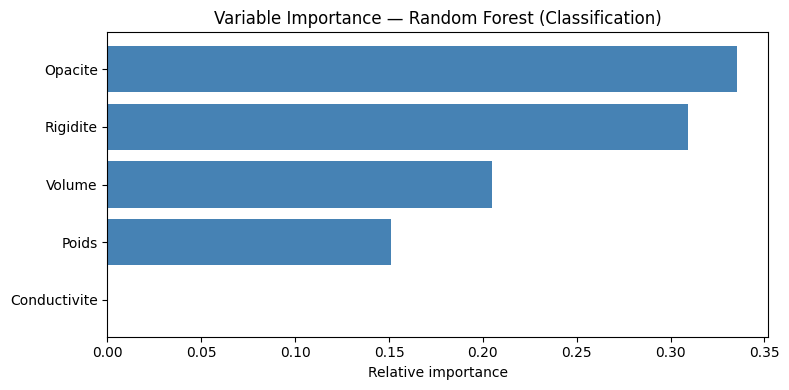

In [12]:
rf_clf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=SEED)
rf_clf.fit(X_tr, y_tr)
y_pred_rf = rf_clf.predict(X_te)

rf_acc  = accuracy_score(y_te, y_pred_rf)
rf_prec = precision_score(y_te, y_pred_rf, average="weighted")
rf_rec  = recall_score(y_te, y_pred_rf, average="weighted")
rf_f1   = f1_score(y_te, y_pred_rf, average="weighted")

print("Confusion matrix Random Forest :")
print(confusion_matrix(y_te, y_pred_rf))
print(f"Accuracy  RF : {rf_acc:.3f}")
print(f"Precision RF : {rf_prec:.3f}")
print(f"Recall    RF : {rf_rec:.3f}")
print(f"F1-score  RF : {rf_f1:.3f}")
print()
print(classification_report(y_te, y_pred_rf, target_names=le.classes_))

# ── Importance des variables ───────────────────────────────────
importances  = rf_clf.feature_importances_
sorted_idx   = np.argsort(importances)
feat_arr     = np.array(feat_classif)
padding      = np.arange(len(feat_classif))

plt.figure(figsize=(8, 4))
plt.barh(padding, importances[sorted_idx], align="center", color="steelblue")
plt.yticks(padding, feat_arr[sorted_idx])
plt.xlabel("Relative importance")
plt.title("Variable Importance — Random Forest (Classification)")
plt.tight_layout()
plt.savefig("outputs/rf_feature_importance_clf.png", dpi=120)
plt.show()

## 8. Modèle SVM (kernel RBF) — Classification

In [13]:
svm_clf = SVC(kernel="rbf", random_state=SEED)
svm_clf.fit(X_tr, y_tr)
y_pred_svm = svm_clf.predict(X_te)

svm_acc  = accuracy_score(y_te, y_pred_svm)
svm_prec = precision_score(y_te, y_pred_svm, average="weighted")
svm_rec  = recall_score(y_te, y_pred_svm, average="weighted")
svm_f1   = f1_score(y_te, y_pred_svm, average="weighted")

print("Confusion matrix SVM rbf :")
print(confusion_matrix(y_te, y_pred_svm))
print(f"Accuracy  SVM : {svm_acc:.3f}")
print(f"Precision SVM : {svm_prec:.3f}")
print(f"Recall    SVM : {svm_rec:.3f}")
print(f"F1-score  SVM : {svm_f1:.3f}")
print()
print(classification_report(y_te, y_pred_svm, target_names=le.classes_))

Confusion matrix SVM rbf :
[[343   0   0   0]
 [  0 344   4   0]
 [  0   0 419   0]
 [  0   0   0 388]]
Accuracy  SVM : 0.997
Precision SVM : 0.997
Recall    SVM : 0.997
F1-score  SVM : 0.997

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       343
      Papier       1.00      0.99      0.99       348
   Plastique       0.99      1.00      1.00       419
       Verre       1.00      1.00      1.00       388

    accuracy                           1.00      1498
   macro avg       1.00      1.00      1.00      1498
weighted avg       1.00      1.00      1.00      1498



## 9. Modèle Logistic Regression — Classification

In [14]:
lr_clf = LogisticRegression(max_iter=1000, random_state=SEED)
lr_clf.fit(X_tr, y_tr)
y_pred_lr = lr_clf.predict(X_te)

lr_acc  = accuracy_score(y_te, y_pred_lr)
lr_prec = precision_score(y_te, y_pred_lr, average="weighted")
lr_rec  = recall_score(y_te, y_pred_lr, average="weighted")
lr_f1   = f1_score(y_te, y_pred_lr, average="weighted")

print("Confusion matrix Logistic Regression :")
print(confusion_matrix(y_te, y_pred_lr))
print(f"Accuracy  LR : {lr_acc:.3f}")
print(f"Precision LR : {lr_prec:.3f}")
print(f"Recall    LR : {lr_rec:.3f}")
print(f"F1-score  LR : {lr_f1:.3f}")
print()
print(classification_report(y_te, y_pred_lr, target_names=le.classes_))

Confusion matrix Logistic Regression :
[[343   0   0   0]
 [  0 347   1   0]
 [  0   6 413   0]
 [  4   0   0 384]]
Accuracy  LR : 0.993
Precision LR : 0.993
Recall    LR : 0.993
F1-score  LR : 0.993

              precision    recall  f1-score   support

       Métal       0.99      1.00      0.99       343
      Papier       0.98      1.00      0.99       348
   Plastique       1.00      0.99      0.99       419
       Verre       1.00      0.99      0.99       388

    accuracy                           0.99      1498
   macro avg       0.99      0.99      0.99      1498
weighted avg       0.99      0.99      0.99      1498



## 10. Modèle Gradient Boosting — Classification

In [15]:
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                     max_depth=3, random_state=SEED)
gb_clf.fit(X_tr, y_tr)
y_pred_gb = gb_clf.predict(X_te)

gb_acc  = accuracy_score(y_te, y_pred_gb)
gb_prec = precision_score(y_te, y_pred_gb, average="weighted")
gb_rec  = recall_score(y_te, y_pred_gb, average="weighted")
gb_f1   = f1_score(y_te, y_pred_gb, average="weighted")

print("Confusion matrix Gradient Boosting :")
print(confusion_matrix(y_te, y_pred_gb))
print(f"Accuracy  GB : {gb_acc:.3f}")
print(f"Precision GB : {gb_prec:.3f}")
print(f"Recall    GB : {gb_rec:.3f}")
print(f"F1-score  GB : {gb_f1:.3f}")
print()
print(classification_report(y_te, y_pred_gb, target_names=le.classes_))

Confusion matrix Gradient Boosting :
[[343   0   0   0]
 [  0 348   0   0]
 [  0   0 419   0]
 [  0   0   0 388]]
Accuracy  GB : 1.000
Precision GB : 1.000
Recall    GB : 1.000
F1-score  GB : 1.000

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       343
      Papier       1.00      1.00      1.00       348
   Plastique       1.00      1.00      1.00       419
       Verre       1.00      1.00      1.00       388

    accuracy                           1.00      1498
   macro avg       1.00      1.00      1.00      1498
weighted avg       1.00      1.00      1.00      1498



## 11. Optimisation — GridSearchCV sur KNN

> Même approche que dans les TP de la prof.

In [16]:
parameters = {"n_neighbors": [1,3,5,7,9,11,13]}
model_gs   = KNeighborsClassifier()
clf_gs     = GridSearchCV(model_gs, parameters, scoring="f1_weighted", cv=5)
grille     = clf_gs.fit(X_tr, y_tr)

print("Meilleur paramètre :", grille.best_params_)
print("Meilleur score CV  :", round(grille.best_score_, 4))

y_pred_knn_opt = grille.predict(X_te)
knn_opt_acc = accuracy_score(y_te, y_pred_knn_opt)
knn_opt_f1  = f1_score(y_te, y_pred_knn_opt, average="weighted")
print(f"\nAccuracy KNN optimisé : {knn_opt_acc:.3f}")
print(f"F1-score KNN optimisé : {knn_opt_f1:.3f}")

Meilleur paramètre : {'n_neighbors': 1}
Meilleur score CV  : 1.0

Accuracy KNN optimisé : 1.000
F1-score KNN optimisé : 1.000


## 12. Optimisation — GridSearchCV sur Random Forest

In [17]:
param_rf = {
    "n_estimators" : [100, 200],
    "max_depth"    : [None, 5, 10],
    "min_samples_split": [2, 5],
}
gs_rf    = GridSearchCV(RandomForestClassifier(random_state=SEED, class_weight="balanced"),
                        param_rf, scoring="f1_weighted", cv=5, n_jobs=-1)
gs_rf.fit(X_tr, y_tr)

print("Meilleur paramètre RF :", gs_rf.best_params_)
print("Meilleur score CV     :", round(gs_rf.best_score_, 4))

y_pred_rf_opt = gs_rf.predict(X_te)
rf_opt_acc = accuracy_score(y_te, y_pred_rf_opt)
rf_opt_f1  = f1_score(y_te, y_pred_rf_opt, average="weighted")
print(f"\nAccuracy RF optimisé : {rf_opt_acc:.3f}")
print(f"F1-score RF optimisé : {rf_opt_f1:.3f}")

Meilleur paramètre RF : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Meilleur score CV     : 1.0

Accuracy RF optimisé : 1.000
F1-score RF optimisé : 1.000


## 13. Résumé comparatif — Classification

| Algorithme          | Accuracy | Precision | Recall  | F1-score |
| ------------------- | -------- | --------- | ------- | -------- |
| KNN (k=5)           | 1.000    | 1.000     | 1.000   | 1.000    |
| Decision Tree       | 1.000    | 1.000     | 1.000   | 1.000    |
| Random Forest       | 1.000    | 1.000     | 1.000   | 1.000    |
| SVM rbf             | 0.997    | 0.997     | 0.997   | 0.997    |
| Logistic Regression | 0.993    | 0.993     | 0.993   | 0.993    |
| Gradient Boosting   | 1.000    | 1.000     | 1.000   | 1.000    |
| KNN optimisé (GS)   | 1.000    | -         | -       | 1.000    |
| RF optimisé (GS)    | 1.000    | -         | -       | 1.000    |


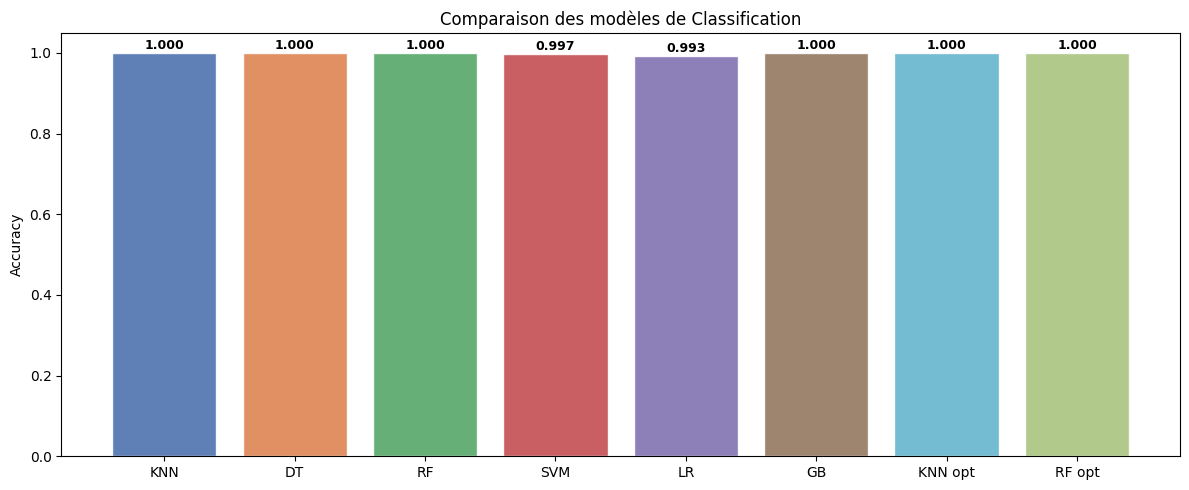

In [18]:
print("| Algorithme          | Accuracy | Precision | Recall  | F1-score |")
print("| ------------------- | -------- | --------- | ------- | -------- |")
print(f"| KNN (k=5)           | {knn_acc:.3f}    | {knn_prec:.3f}     | {knn_rec:.3f}   | {knn_f1:.3f}    |")
print(f"| Decision Tree       | {dt_acc:.3f}    | {dt_prec:.3f}     | {dt_rec:.3f}   | {dt_f1:.3f}    |")
print(f"| Random Forest       | {rf_acc:.3f}    | {rf_prec:.3f}     | {rf_rec:.3f}   | {rf_f1:.3f}    |")
print(f"| SVM rbf             | {svm_acc:.3f}    | {svm_prec:.3f}     | {svm_rec:.3f}   | {svm_f1:.3f}    |")
print(f"| Logistic Regression | {lr_acc:.3f}    | {lr_prec:.3f}     | {lr_rec:.3f}   | {lr_f1:.3f}    |")
print(f"| Gradient Boosting   | {gb_acc:.3f}    | {gb_prec:.3f}     | {gb_rec:.3f}   | {gb_f1:.3f}    |")
print(f"| KNN optimisé (GS)   | {knn_opt_acc:.3f}    | -         | -       | {knn_opt_f1:.3f}    |")
print(f"| RF optimisé (GS)    | {rf_opt_acc:.3f}    | -         | -       | {rf_opt_f1:.3f}    |")

# ── Graphique comparatif ───────────────────────────────────────
algos  = ["KNN","DT","RF","SVM","LR","GB","KNN opt","RF opt"]
scores = [knn_acc,dt_acc,rf_acc,svm_acc,lr_acc,gb_acc,knn_opt_acc,rf_opt_acc]
colors = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2","#937860","#64B5CD","#A9C47F"]

fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(algos, scores, color=colors, edgecolor="white", alpha=0.9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Comparaison des modèles de Classification")
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{score:.3f}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/classification_comparison.png", dpi=120)
plt.show()

## 14. SHAP Values — Sélection des features (meilleur modèle Classification)

> Interprétabilité du modèle via SHAP. Permet de justifier quelles features contribuent le plus.

In [36]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
if SHAP_OK:
    # Utiliser le meilleur modèle (RF ou GB selon vos résultats)
    best_model_clf = gs_rf.best_estimator_

    explainer_clf = shap.TreeExplainer(best_model_clf)
    shap_values   = explainer_clf.shap_values(X_te)

    print("SHAP Summary Plot — Classification (Random Forest optimisé) :")
    shap.summary_plot(shap_values, X_te, feature_names=feat_classif,
                      class_names=list(le.classes_), show=True)

    # SHAP bar plot (importance globale multi-classes)
    shap.summary_plot(shap_values, X_te, feature_names=feat_classif,
                      plot_type="bar", class_names=list(le.classes_), show=True)
else:
    print("⚠️  SHAP non disponible — installer avec : pip install shap")
    # Fallback : importance Random Forest
    importances = gs_rf.best_estimator_.feature_importances_
    feat_imp    = pd.Series(importances, index=feat_classif).sort_values(ascending=False)
    print("\nImportance des features (Random Forest) :")
    display(feat_imp.to_frame("importance").style.bar(color="#4C72B0"))

⚠️  SHAP non disponible — installer avec : pip install shap

Importance des features (Random Forest) :


,importance
Opacite,0.327071
Rigidite,0.309189
Volume,0.208597
Poids,0.155143
Conductivite,0.000000


---
#  PARTIE B — Régression : Prédire `Prix_Revente`

## 15. Préparation X, Y et split Train/Test (80:20)


In [39]:
# ── Features pour la régression ──────────────────────────────
feat_reg = [c for c in NUMERICAL_FEATURES if c in df_clean.columns] + ["Categorie_encoded"]
feat_reg = [c for c in feat_reg if c != REGRESSION_TARGET]

print(f"Features régression : {feat_reg}")

X_reg = df_clean[feat_reg].values
Y_reg = df_clean[REGRESSION_TARGET].values

print(f"Shape X : {X_reg.shape}")
print(f"Shape Y : {Y_reg.shape}")
print(f"Stats Y : min={Y_reg.min():.2f}  max={Y_reg.max():.2f}  mean={Y_reg.mean():.2f}")

# ── Standardisation ────────────────────────────────────────────
scaler_reg   = StandardScaler()
X_reg_sc     = scaler_reg.fit_transform(X_reg)

# ── Split 80 / 20 ──────────────────────────────────────────────
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg_sc, Y_reg, test_size=0.20, random_state=SEED)

print(f"\nTrain : {len(X_train_r)} | Test : {len(X_test_r)}")

Features régression : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie_encoded']
Shape X : (9986, 6)
Shape Y : (9986,)
Stats Y : min=-6.52  max=14.73  mean=5.61

Train : 7988 | Test : 1998


## 16. Fonction de métriques de régression

In [ ]:
def metriques_reg(name_model, y_test, y_pred):
    """Affiche MAE, MSE, RMSE, R² — même style que les TP de la prof."""
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-9))) * 100

    print(f"{'='*40}")
    print(f"Métriques de : {name_model}")
    print(f"{'='*40}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    return r2, mae, mse, rmse, mape

print("Fonction metriques_reg définie ")

Fonction metriques_reg définie ✅


## 17. Régression Linéaire

In [41]:
lr_reg = LinearRegression()
lr_reg.fit(X_train_r, y_train_r)
y_pred_lr_reg = lr_reg.predict(X_test_r)

r2_lr, mae_lr, mse_lr, rmse_lr, mape_lr = metriques_reg(
    "Régression Linéaire", y_test_r, y_pred_lr_reg)

# Vérification 10 premières prédictions
print("\n10 premières prédictions vs réel :")
for i in range(10):
    print(f"  Réel: {y_test_r[i]:.2f}  |  Prédit: {y_pred_lr_reg[i]:.2f}")

Métriques de : Régression Linéaire
  MAE  : 1.3994
  MSE  : 3.3653
  RMSE : 1.8345
  R²   : 0.8637
  MAPE : 83.52%

10 premières prédictions vs réel :
  Réel: 14.73  |  Prédit: 12.34
  Réel: 2.23  |  Prédit: 1.18
  Réel: 13.14  |  Prédit: 14.47
  Réel: 14.73  |  Prédit: 11.88
  Réel: 3.85  |  Prédit: 1.43
  Réel: 4.01  |  Prédit: 3.15
  Réel: 0.67  |  Prédit: 1.33
  Réel: 7.09  |  Prédit: 7.82
  Réel: 4.95  |  Prédit: 5.12
  Réel: 14.73  |  Prédit: 13.81


## 18. Régression Ridge (L2)

In [42]:
ridge = Ridge()
ridge.fit(X_train_r, y_train_r)
y_pred_ridge = ridge.predict(X_test_r)

r2_ridge, mae_ridge, mse_ridge, rmse_ridge, mape_ridge = metriques_reg(
    "Ridge", y_test_r, y_pred_ridge)

Métriques de : Ridge
  MAE  : 1.3997
  MSE  : 3.3656
  RMSE : 1.8346
  R²   : 0.8637
  MAPE : 83.53%


## 19. Régression Lasso (L1)

In [43]:
lasso = Lasso()
lasso.fit(X_train_r, y_train_r)
y_pred_lasso = lasso.predict(X_test_r)

r2_lasso, mae_lasso, mse_lasso, rmse_lasso, mape_lasso = metriques_reg(
    "Lasso", y_test_r, y_pred_lasso)

Métriques de : Lasso
  MAE  : 2.0018
  MSE  : 6.4425
  RMSE : 2.5382
  R²   : 0.7391
  MAPE : 120.41%


## 20. Decision Tree Regressor

In [44]:
dt_reg = DecisionTreeRegressor(random_state=SEED)
dt_reg.fit(X_train_r, y_train_r)
y_pred_dt_reg = dt_reg.predict(X_test_r)

r2_dt_reg, mae_dt_reg, mse_dt_reg, rmse_dt_reg, mape_dt_reg = metriques_reg(
    "DecisionTreeRegressor", y_test_r, y_pred_dt_reg)

Métriques de : DecisionTreeRegressor
  MAE  : 0.0364
  MSE  : 0.2342
  RMSE : 0.4840
  R²   : 0.9905
  MAPE : 1.51%


## 21. Random Forest Regressor

Métriques de : RandomForestRegressor
  MAE  : 0.0352
  MSE  : 0.1753
  RMSE : 0.4187
  R²   : 0.9929
  MAPE : 1.34%


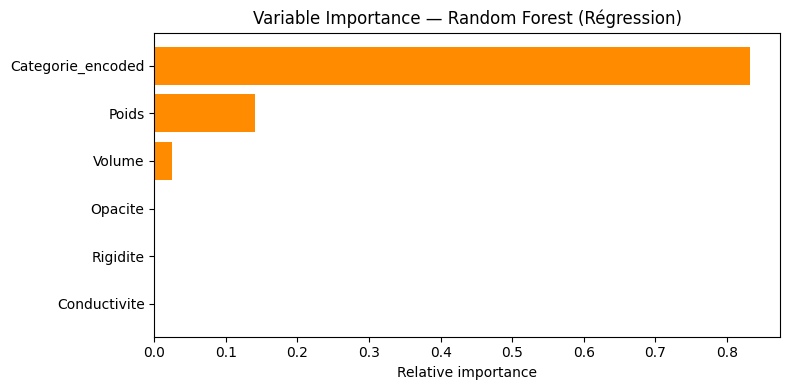

In [45]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=SEED)
rf_reg.fit(X_train_r, y_train_r)
y_pred_rf_reg = rf_reg.predict(X_test_r)

r2_rf_reg, mae_rf_reg, mse_rf_reg, rmse_rf_reg, mape_rf_reg = metriques_reg(
    "RandomForestRegressor", y_test_r, y_pred_rf_reg)

# ── Importance des variables ───────────────────────────────────
importances_r = rf_reg.feature_importances_
sorted_idx_r  = np.argsort(importances_r)
feat_arr_r    = np.array(feat_reg)
pad_r         = np.arange(len(feat_reg))

plt.figure(figsize=(8,4))
plt.barh(pad_r, importances_r[sorted_idx_r], align="center", color="darkorange")
plt.yticks(pad_r, feat_arr_r[sorted_idx_r])
plt.xlabel("Relative importance")
plt.title("Variable Importance — Random Forest (Régression)")
plt.tight_layout()
plt.savefig("outputs/rf_feature_importance_reg.png", dpi=120)
plt.show()

## 22. Gradient Boosting Regressor

In [46]:
gb_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                    max_depth=3, random_state=SEED)
gb_reg.fit(X_train_r, y_train_r)
y_pred_gb_reg = gb_reg.predict(X_test_r)

r2_gb_reg, mae_gb_reg, mse_gb_reg, rmse_gb_reg, mape_gb_reg = metriques_reg(
    "GradientBoostingRegressor", y_test_r, y_pred_gb_reg)

Métriques de : GradientBoostingRegressor
  MAE  : 0.1674
  MSE  : 0.2331
  RMSE : 0.4828
  R²   : 0.9906
  MAPE : 6.74%


## 23. KNN Regressor

In [47]:
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_r, y_train_r)
y_pred_knn_reg = knn_reg.predict(X_test_r)

r2_knn_reg, mae_knn_reg, mse_knn_reg, rmse_knn_reg, mape_knn_reg = metriques_reg(
    "KNN Regressor", y_test_r, y_pred_knn_reg)

Métriques de : KNN Regressor
  MAE  : 0.0421
  MSE  : 0.1846
  RMSE : 0.4296
  R²   : 0.9925
  MAPE : 1.43%


## 24. Optimisation — GridSearchCV sur Random Forest Regressor

In [48]:
param_rf_r = {
    "n_estimators" : [100, 200],
    "max_depth"    : [None, 5, 10],
    "min_samples_split": [2, 5],
}
gs_rf_reg = GridSearchCV(
    RandomForestRegressor(random_state=SEED),
    param_rf_r, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
gs_rf_reg.fit(X_train_r, y_train_r)

print("Meilleur paramètre RF Reg :", gs_rf_reg.best_params_)
print("Meilleur score CV (neg MSE):", round(gs_rf_reg.best_score_, 4))

y_pred_rf_opt_reg = gs_rf_reg.predict(X_test_r)
r2_rf_opt, mae_rf_opt, mse_rf_opt, rmse_rf_opt, mape_rf_opt = metriques_reg(
    "RF Regressor optimisé (GridSearch)", y_test_r, y_pred_rf_opt_reg)

Meilleur paramètre RF Reg : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Meilleur score CV (neg MSE): -0.3667
Métriques de : RF Regressor optimisé (GridSearch)
  MAE  : 0.0618
  MSE  : 0.1775
  RMSE : 0.4213
  R²   : 0.9928
  MAPE : 2.24%


## 25. SHAP Values — Régression (meilleur modèle)

> Identification des features les plus importantes pour la prédiction du prix.

In [49]:
if SHAP_OK:
    best_model_reg = gs_rf_reg.best_estimator_
    explainer_reg  = shap.TreeExplainer(best_model_reg)
    shap_values_r  = explainer_reg.shap_values(X_test_r)

    print("SHAP Summary Plot — Régression (RF optimisé) :")
    shap.summary_plot(shap_values_r, X_test_r, feature_names=feat_reg, show=True)
    shap.summary_plot(shap_values_r, X_test_r, feature_names=feat_reg,
                      plot_type="bar", show=True)
else:
    print("⚠️  SHAP non disponible — affichage importance RF :")
    importances_r2 = gs_rf_reg.best_estimator_.feature_importances_
    feat_imp_r2    = pd.Series(importances_r2, index=feat_reg).sort_values(ascending=False)
    display(feat_imp_r2.to_frame("importance").style.bar(color="darkorange"))

⚠️  SHAP non disponible — affichage importance RF :


,importance
Categorie_encoded,0.833265
Poids,0.139321
Volume,0.024979
Opacite,0.001757
Rigidite,0.000677
Conductivite,0.000000


## 26. Résumé comparatif — Régression

| Algorithme               | R²     | MAE     | MSE      | RMSE    |
| ------------------------ | ------ | ------- | -------- | ------- |
| Régression Linéaire      | 0.864 | 1.399   | 3.365  | 1.834   |
| Ridge                    | 0.864 | 1.400   | 3.366  | 1.835   |
| Lasso                    | 0.739 | 2.002   | 6.443  | 2.538   |
| DecisionTreeRegressor    | 0.991 | 0.036   | 0.234  | 0.484   |
| RandomForestRegressor    | 0.993 | 0.035   | 0.175  | 0.419   |
| GradientBoostingRegressor| 0.991 | 0.167   | 0.233  | 0.483   |
| KNN Regressor            | 0.993 | 0.042   | 0.185  | 0.430   |
| RF opt (GridSearch)      | 0.993 | 0.062   | 0.178  | 0.421   |


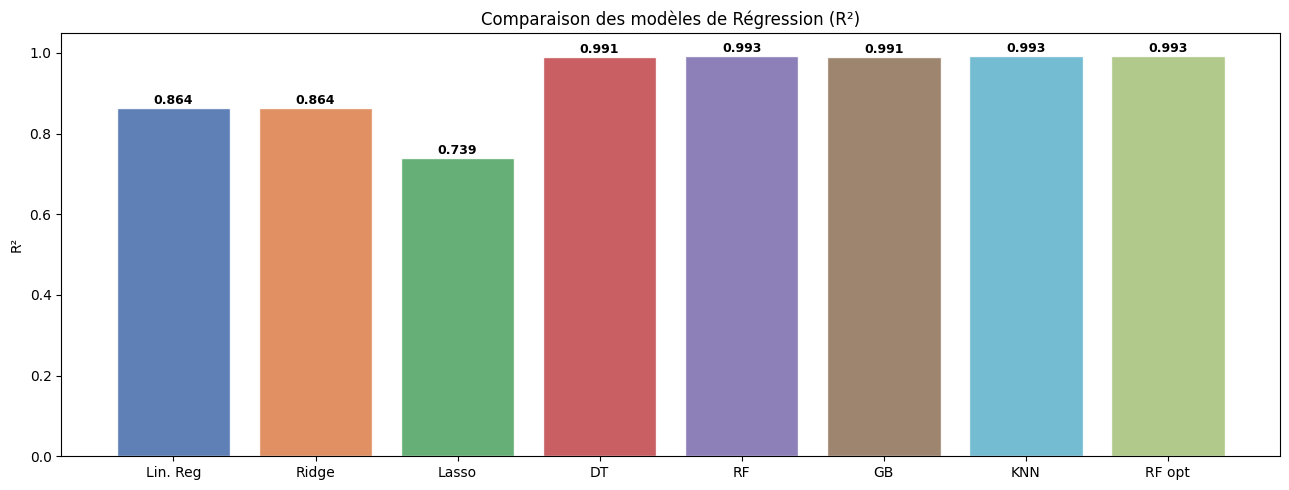

In [50]:
print("| Algorithme               | R²     | MAE     | MSE      | RMSE    |")
print("| ------------------------ | ------ | ------- | -------- | ------- |")
print(f"| Régression Linéaire      | {r2_lr:.3f} | {mae_lr:.3f}   | {mse_lr:.3f}  | {rmse_lr:.3f}   |")
print(f"| Ridge                    | {r2_ridge:.3f} | {mae_ridge:.3f}   | {mse_ridge:.3f}  | {rmse_ridge:.3f}   |")
print(f"| Lasso                    | {r2_lasso:.3f} | {mae_lasso:.3f}   | {mse_lasso:.3f}  | {rmse_lasso:.3f}   |")
print(f"| DecisionTreeRegressor    | {r2_dt_reg:.3f} | {mae_dt_reg:.3f}   | {mse_dt_reg:.3f}  | {rmse_dt_reg:.3f}   |")
print(f"| RandomForestRegressor    | {r2_rf_reg:.3f} | {mae_rf_reg:.3f}   | {mse_rf_reg:.3f}  | {rmse_rf_reg:.3f}   |")
print(f"| GradientBoostingRegressor| {r2_gb_reg:.3f} | {mae_gb_reg:.3f}   | {mse_gb_reg:.3f}  | {rmse_gb_reg:.3f}   |")
print(f"| KNN Regressor            | {r2_knn_reg:.3f} | {mae_knn_reg:.3f}   | {mse_knn_reg:.3f}  | {rmse_knn_reg:.3f}   |")
print(f"| RF opt (GridSearch)      | {r2_rf_opt:.3f} | {mae_rf_opt:.3f}   | {mse_rf_opt:.3f}  | {rmse_rf_opt:.3f}   |")

# ── Graphique R² comparatif ────────────────────────────────────
algos_r  = ["Lin. Reg","Ridge","Lasso","DT","RF","GB","KNN","RF opt"]
r2_vals  = [r2_lr,r2_ridge,r2_lasso,r2_dt_reg,r2_rf_reg,r2_gb_reg,r2_knn_reg,r2_rf_opt]
cols_r   = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2","#937860","#64B5CD","#A9C47F"]

fig, ax = plt.subplots(figsize=(13,5))
bars = ax.bar(algos_r, r2_vals, color=cols_r, edgecolor="white", alpha=0.9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("R²")
ax.set_title("Comparaison des modèles de Régression (R²)")
for bar, score in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{score:.3f}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/regression_comparison.png", dpi=120)
plt.show()

## 27. Courbe REC (Regression Error Characteristic)

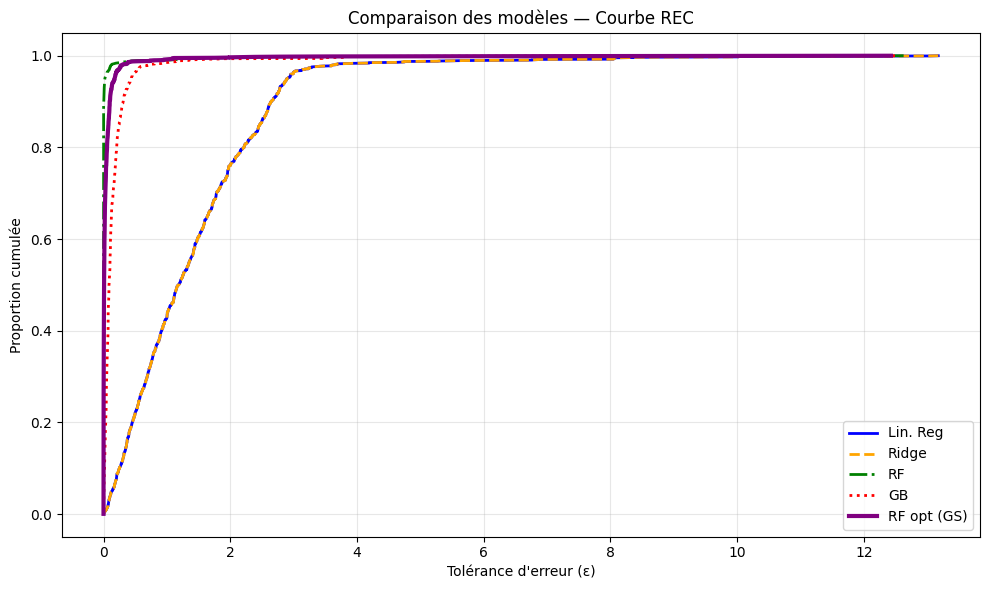

In [51]:
def rec_curve(y_true, y_pred):
    errors         = np.abs(y_true - y_pred)
    sorted_errors  = np.sort(errors)
    accuracy       = np.arange(1, len(errors)+1) / len(errors)
    return sorted_errors, accuracy

models_reg_preds = {
    "Lin. Reg"   : y_pred_lr_reg,
    "Ridge"      : y_pred_ridge,
    "RF"         : y_pred_rf_reg,
    "GB"         : y_pred_gb_reg,
    "RF opt (GS)": y_pred_rf_opt_reg,
}
styles_rec = {
    "Lin. Reg"   : {"color": "blue",   "linestyle": "-",   "linewidth": 2},
    "Ridge"      : {"color": "orange", "linestyle": "--",  "linewidth": 2},
    "RF"         : {"color": "green",  "linestyle": "-.",  "linewidth": 2},
    "GB"         : {"color": "red",    "linestyle": ":",   "linewidth": 2},
    "RF opt (GS)": {"color": "purple", "linestyle": "-",   "linewidth": 3},
}

plt.figure(figsize=(10, 6))
for name, y_pred in models_reg_preds.items():
    thr, acc = rec_curve(y_test_r, y_pred)
    plt.plot(thr, acc, label=name, **styles_rec[name])

plt.xlabel("Tolérance d'erreur (ε)")
plt.ylabel("Proportion cumulée")
plt.title("Comparaison des modèles — Courbe REC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/rec_curve_regression.png", dpi=120)
plt.show()

## 28. Conclusion & Meilleur modèle

In [ ]:
print("=" * 60)
print("RÉSUMÉ MODULE 2")
print("=" * 60)

# ── Meilleur modèle classification ───────────────────────────
clf_results = {
    "KNN":knn_f1,"Decision Tree":dt_f1,"Random Forest":rf_f1,
    "SVM":svm_f1,"Logistic Reg":lr_f1,"Gradient Boosting":gb_f1,
    "KNN opt":knn_opt_f1,"RF opt":rf_opt_f1
}
best_clf_name = max(clf_results, key=clf_results.get)
best_clf_f1   = clf_results[best_clf_name]
print(f"\n Meilleur modèle CLASSIFICATION : {best_clf_name}")
print(f"   F1-score weighted : {best_clf_f1:.3f}")

# ── Meilleur modèle régression ────────────────────────────────
reg_results = {
    "Lin. Reg":r2_lr,"Ridge":r2_ridge,"Lasso":r2_lasso,
    "DT Reg":r2_dt_reg,"RF Reg":r2_rf_reg,"GB Reg":r2_gb_reg,
    "KNN Reg":r2_knn_reg,"RF opt":r2_rf_opt
}
best_reg_name = max(reg_results, key=reg_results.get)
best_reg_r2   = reg_results[best_reg_name]
print(f"\n Meilleur modèle RÉGRESSION : {best_reg_name}")
print(f"   R² : {best_reg_r2:.3f}")
print()
print("Figures sauvegardées dans outputs/")

RÉSUMÉ MODULE 2

🏆 Meilleur modèle CLASSIFICATION : KNN
   F1-score weighted : 1.000

🏆 Meilleur modèle RÉGRESSION : RF Reg
   R² : 0.993

Figures sauvegardées dans outputs/
